**Install Dependencies**

In [2]:
!pip install --quiet imageio scipy

**Download & extract TUM RGB-D dataset (freiburg1_xyz)**

In [3]:
!wget -q http://vision.in.tum.de/rgbd/dataset/freiburg1/rgbd_dataset_freiburg1_xyz.tgz
!tar -xvzf rgbd_dataset_freiburg1_xyz.tgz

rgbd_dataset_freiburg1_xyz/
rgbd_dataset_freiburg1_xyz/accelerometer.txt
rgbd_dataset_freiburg1_xyz/rgb/
rgbd_dataset_freiburg1_xyz/rgb/1305031107.143260.png
rgbd_dataset_freiburg1_xyz/rgb/1305031125.650575.png
rgbd_dataset_freiburg1_xyz/rgb/1305031106.711508.png
rgbd_dataset_freiburg1_xyz/rgb/1305031119.747193.png
rgbd_dataset_freiburg1_xyz/rgb/1305031114.211303.png
rgbd_dataset_freiburg1_xyz/rgb/1305031103.743326.png
rgbd_dataset_freiburg1_xyz/rgb/1305031124.249327.png
rgbd_dataset_freiburg1_xyz/rgb/1305031103.543444.png
rgbd_dataset_freiburg1_xyz/rgb/1305031124.850535.png
rgbd_dataset_freiburg1_xyz/rgb/1305031105.211268.png
rgbd_dataset_freiburg1_xyz/rgb/1305031110.311404.png
rgbd_dataset_freiburg1_xyz/rgb/1305031107.343509.png
rgbd_dataset_freiburg1_xyz/rgb/1305031112.043270.png
rgbd_dataset_freiburg1_xyz/rgb/1305031107.411271.png
rgbd_dataset_freiburg1_xyz/rgb/1305031120.315196.png
rgbd_dataset_freiburg1_xyz/rgb/1305031106.075330.png
rgbd_dataset_freiburg1_xyz/rgb/1305031114.57923

**Import libraries**

In [4]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace

**Load RGB-D frame**

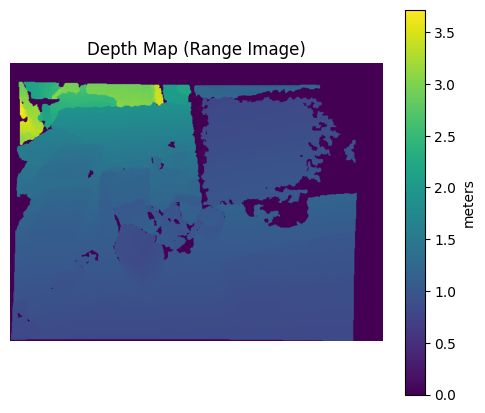

In [5]:
rgb_dir = "rgbd_dataset_freiburg1_xyz/rgb"
depth_dir = "rgbd_dataset_freiburg1_xyz/depth"

rgb_files = sorted(os.listdir(rgb_dir))
depth_files = sorted(os.listdir(depth_dir))

# Take one depth frame
depth = imageio.v2.imread(os.path.join(depth_dir, depth_files[10])).astype(np.float32) / 5000.0  # meters

# Display depth map
plt.figure(figsize=(6,5))
plt.imshow(depth, cmap="viridis")
plt.colorbar(label="meters")
plt.title("Depth Map (Range Image)")
plt.axis("off")
plt.show()

**Step 1: Detect Step Edges (Depth Discontinuities)**

    
    Formula: Step edge if |z(i,j) - z(i+1,j)| > T
        

In [6]:
# Compute gradients (1st derivative)
dz_dx = np.abs(np.diff(depth, axis=1))
dz_dy = np.abs(np.diff(depth, axis=0))

# Pad to original size
dz_dx = np.pad(dz_dx, ((0,0),(0,1)), mode="constant")
dz_dy = np.pad(dz_dy, ((0,1),(0,0)), mode="constant")

# Combine gradient magnitude
grad_mag = np.sqrt(dz_dx**2 + dz_dy**2)

# Threshold for step edges
T = 0.05  # 5 cm difference
step_edges = (grad_mag > T).astype(np.uint8)

**Step 2: Detect Roof Edges (Ridge/Valley)**


    Formula: Roof edge if 2nd derivative (Laplacian) crosses zero

In [7]:
depth_smooth = gaussian_filter(depth, sigma=1)  # smooth to reduce noise
lap = laplace(depth_smooth)  # second derivative

# Roof edge detection: zero-crossings of Laplacian
roof_edges = np.zeros_like(lap, dtype=np.uint8)
roof_edges[np.where(np.diff(np.sign(lap), axis=0))] = 1
roof_edges[np.where(np.diff(np.sign(lap), axis=1))] = 1

**Step 3: Visualization**


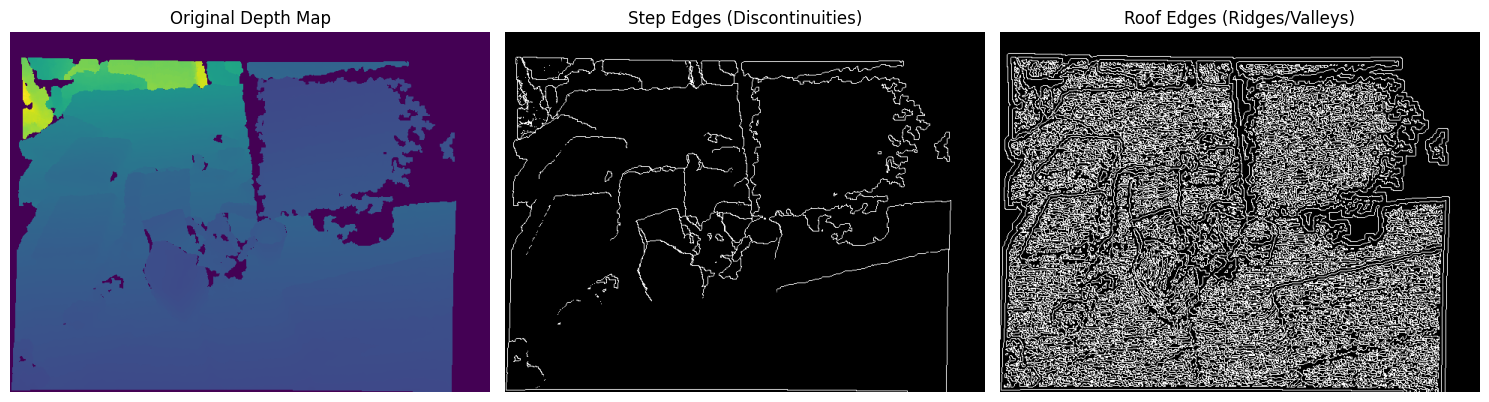

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(depth, cmap="viridis")
plt.title("Original Depth Map")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(step_edges, cmap="gray")
plt.title("Step Edges (Discontinuities)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(roof_edges, cmap="gray")
plt.title("Roof Edges (Ridges/Valleys)")
plt.axis("off")

plt.tight_layout()
plt.show()